In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx

Text(0.5, 1.0, 'Databases Redudancy (>95% identity)')

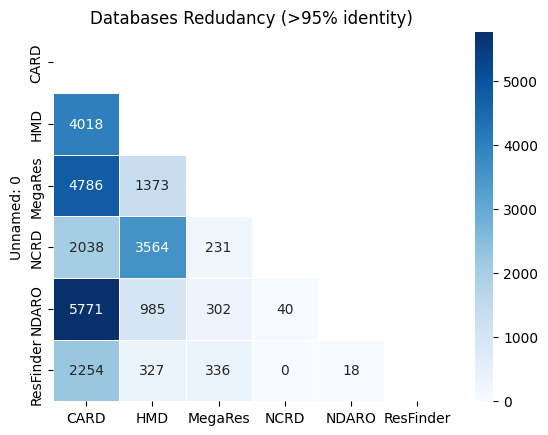

In [ ]:
BlastPairWiseAlignmentPivoted = pd.read_csv("../data/processed/BlastPairWiseAlignmentPivoted.cov80.maxseq1.csv", sep="\t")
mask = np.triu(np.ones_like(BlastPairWiseAlignmentPivoted.set_index("Unnamed: 0"), dtype=bool)) 
sns.heatmap(
    BlastPairWiseAlignmentPivoted.set_index("Unnamed: 0"),
    cmap="Blues",
    annot=True,
    fmt=".0f",
    linewidth=.5,
    mask=mask,
)
plt.title("Databases Redudancy (>95% identity)")

In [ ]:
BlastPairWiseAlignmentPivoted

,Unnamed: 0,CARD,HMD,MegaRes,NCRD,NDARO,ResFinder
0,CARD,25.0,2866.0,1774.0,84.0,1285.0,0.0
1,HMD,4018.0,6921.0,1283.0,1988.0,264.0,6.0
2,MegaRes,4786.0,1373.0,164.0,67.0,241.0,196.0
3,NCRD,2038.0,3564.0,231.0,4963.0,65.0,1.0
4,NDARO,5771.0,985.0,302.0,40.0,69.0,15.0
5,ResFinder,2254.0,327.0,336.0,0.0,18.0,10.0


Text(0, 0.5, 'Database Size')

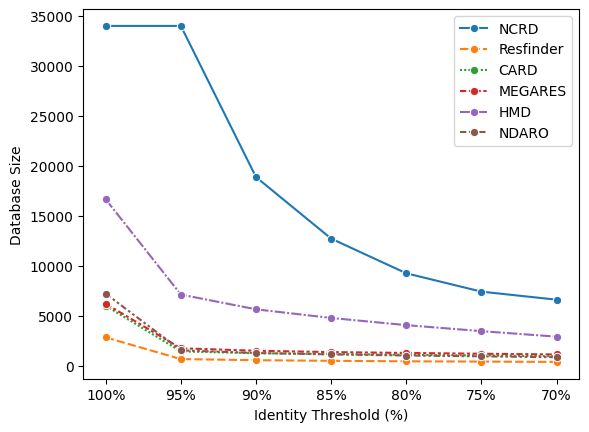

In [ ]:
ClustersCdHit = pd.read_csv(
    "../data/processed/cdhitclusters.defaultsettings.csv",
    sep = "\t",
)
sns.lineplot(
    ClustersCdHit.set_index("Unnamed: 0"),
    marker = "o"
)
plt.xlabel("Identity Threshold (%)")
plt.ylabel("Database Size")

In [ ]:
ClustersCdHit

,Unnamed: 0,NCRD,Resfinder,CARD,MEGARES,HMD,NDARO
0,100%,34008,2861,6023,6220,16666,7237
1,95%,34008,694,1463,1774,7147,1572
2,90%,18893,583,1284,1527,5670,1299
3,85%,12739,520,1195,1393,4805,1162
4,80%,9273,471,1121,1308,4089,1052
5,75%,7437,444,1054,1228,3487,968
6,70%,6634,410,979,1155,2937,879


In [ ]:
PairWiseAlignment = pd.read_csv(
    "../data/filtered/AllDatabases.Paiwise.cov80.maxseq1.tsv", 
    sep = "\t",
    skipinitialspace=True, 
    header=None,
    names = "qseqid sseqid pident length qlen slen qstart qend sstart send evalue bitscore ppos full_qseq full_sseq".split(" ")
)
PairWiseAlignment["qcov"] = np.round((PairWiseAlignment["qend"] - PairWiseAlignment["qstart"] + 1) / (PairWiseAlignment["qlen"]) * 100, 2)
PairWiseAlignment["scov"] = np.round((PairWiseAlignment["send"] - PairWiseAlignment["sstart"] + 1) / (PairWiseAlignment["slen"]) * 100, 2)
PairWiseAlignment["qseqtag"] = PairWiseAlignment["qseqid"].str.split("|").str[1]
PairWiseAlignment["sseqtag"] = PairWiseAlignment["sseqid"].str.split("|").str[1]
PairWiseAlignment["qseqid"] = PairWiseAlignment["qseqid"].str.split("|").str[0]
PairWiseAlignment["sseqid"] = PairWiseAlignment["sseqid"].str.split("|").str[0]

<Axes: xlabel='qcov', ylabel='pident'>

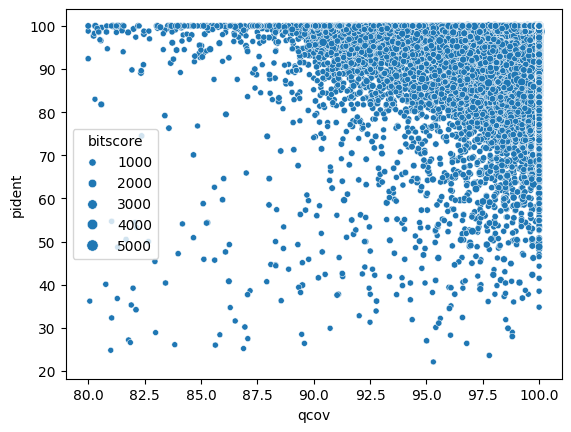

In [ ]:
sns.scatterplot(
    data=PairWiseAlignment.loc[PairWiseAlignment["bitscore"] > 50], 
    x="qcov", 
    y="pident",
    size = "bitscore",
    )

<Axes: xlabel='pident', ylabel='ppos'>

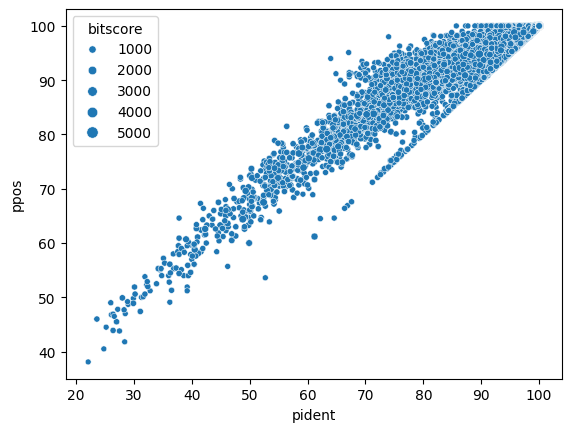

In [ ]:
sns.scatterplot(
    data=PairWiseAlignment.loc[PairWiseAlignment["bitscore"] > 50], 
    x="pident", 
    y="ppos",
    size = "bitscore",
    )

In [ ]:
PairWiseAlignment

,qseqid,sseqid,pident,length,qlen,slen,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,ppos,qcov,scov,qseqtag,sseqtag
0,CARD_0,MEGARES_1086,100.0,296,296,296,0,0,1,296,1,296,5.450000e-215,587.0,100.0,100.0,100.0,CARD,MEGARES
1,CARD_1,HMD_829,100.0,286,286,286,0,0,1,286,1,286,3.770000e-201,551.0,100.0,100.0,100.0,CARD,HMD
2,CARD_2,NCRD_0,100.0,164,164,164,0,0,1,164,1,164,3.050000e-117,328.0,100.0,100.0,100.0,CARD,NCRD
3,CARD_3,HMD_1374,100.0,291,291,291,0,0,1,291,1,291,5.800000e-203,556.0,100.0,100.0,100.0,CARD,HMD
4,CARD_4,HMD_247,100.0,270,270,270,0,0,1,270,1,270,2.760000e-195,535.0,100.0,100.0,100.0,CARD,HMD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74155,RESFINDER_2950,HMD_5549,100.0,283,283,283,0,0,1,283,1,283,1.220000e-200,549.0,100.0,100.0,100.0,RESFINDER,HMD
74156,RESFINDER_2951,MEGARES_4771,100.0,275,275,275,0,0,1,275,1,275,2.870000e-195,535.0,100.0,100.0,100.0,RESFINDER,MEGARES
74157,RESFINDER_2952,HMD_8396,100.0,279,279,279,0,0,1,279,1,279,7.040000e-198,542.0,100.0,100.0,100.0,RESFINDER,HMD
74158,RESFINDER_2953,MEGARES_4770,100.0,279,279,279,0,0,1,279,1,279,1.730000e-198,543.0,100.0,100.0,100.0,RESFINDER,MEGARES


In [ ]:
SequenceSimilarityGraph = nx.from_pandas_edgelist(
    PairWiseAlignment.loc[PairWiseAlignment["bitscore"] > 50], 
    source="qseqid", 
    target="sseqid", 
    edge_attr=["pident", "bitscore", "evalue","bitscore", "ppos"]
)

In [ ]:
ConnectedComponents = list(nx.connected_components(SequenceSimilarityGraph))
len(ConnectedComponents)

16113

In [ ]:
Degree = nx.degree_centrality(SequenceSimilarityGraph)
TopHubs = sorted(Degree.items(), key=lambda x: x[1], reverse=True)[:10]
TopHubs

[('CARD_76', 0.0008089415000471883),
 ('NCRD_29901', 0.0006606355583718705),
 ('CARD_1206', 0.0005932237667012714),
 ('CARD_943', 0.00045840018336007336),
 ('CARD_4807', 0.00044491782502595356),
 ('CARD_1001', 0.00041795310835771396),
 ('CARD_974', 0.00037750603335535456),
 ('CARD_1918', 0.00036402367502123476),
 ('CARD_524', 0.0003370589583529951),
 ('CARD_162', 0.0003235766000188753)]

In [ ]:
Bridges = list(nx.bridges(SequenceSimilarityGraph))
len(Bridges)

58049

In [ ]:
ArtPoints = list(nx.articulation_points(SequenceSimilarityGraph))
len(ArtPoints)

21816

In [ ]:
BetweennessCentrality = nx.betweenness_centrality(SequenceSimilarityGraph)
TopBetweenness = sorted(BetweennessCentrality.items(), key=lambda x: x[1], reverse=True)[:10]
TopBetweenness